In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
caminho_arquivo = 'Tabela_13_Meio_de_transporte.xlsx' 


df = pd.read_excel(caminho_arquivo, sheet_name='Exemplo gráfico Brasil', skiprows=1)
df = df.rename(columns={df.columns[0]: 'Meio de Transporte'})

df

,Meio de Transporte,Branca,Preta ou parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


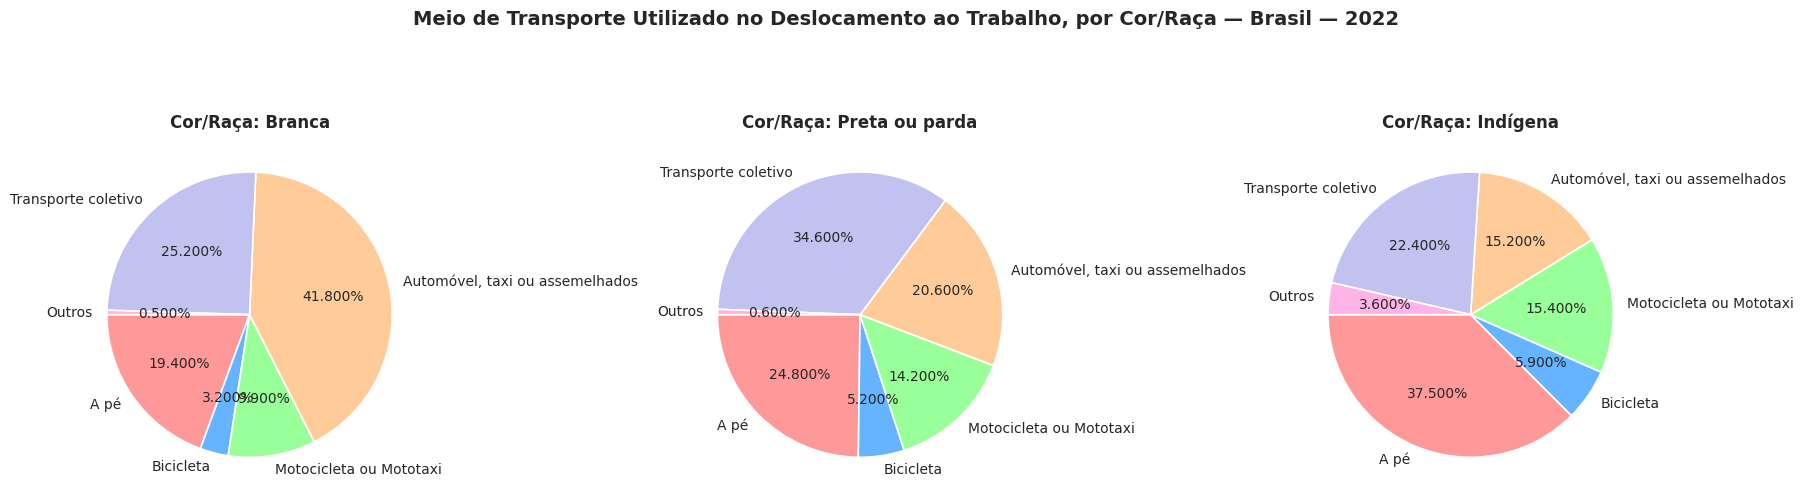

In [3]:
TAMANHO = (18, 6)

fig, axes = plt.subplots(1, 3, figsize=TAMANHO)
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',  
        startangle=180,  
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meio de Transporte Utilizado no Deslocamento ao Trabalho, por Cor/Raça — Brasil — 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [4]:
diferencas = pd.DataFrame({
    'Meio de Transporte': df['Meio de Transporte'],
    'Branca (%)': df['Branca'],
    'Preta ou parda (%)': df['Preta ou parda'],
    'Indígena (%)': df['Indígena'],
    'Dif. Branca - Preta ou parda (p.p.)': (df['Branca'] - df['Preta ou parda']).round(1),
    'Dif. Branca - Indígena (p.p.)': (df['Branca'] - df['Indígena']).round(1),
})

diferencas

,Meio de Transporte,Branca (%),Preta ou parda (%),Indígena (%),Dif. Branca - Preta ou parda (p.p.),Dif. Branca - Indígena (p.p.)
0,A pé,19.4,24.8,37.5,-5.4,-18.1
1,Bicicleta,3.2,5.2,5.9,-2.0,-2.7
2,Motocicleta ou Mototaxi,9.9,14.2,15.4,-4.3,-5.5
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2,21.2,26.6
4,Transporte coletivo,25.2,34.6,22.4,-9.4,2.8
5,Outros,0.5,0.6,3.6,-0.1,-3.1


### Análise dos gráficos — diferença entre meios de transporte por cor/raça

Comparando **mulheres brancas** com **mulheres pretas ou pardas** (diferença em pontos percentuais, p.p.):

- **A pé** — Brancas 19,4% x Pretas ou pardas 24,8% → pretas ou pardas andam 5,4 p.p. a mais a pé
- **Bicicleta** — Brancas 3,2% x Pretas ou pardas 5,2% → pretas ou pardas usam 2,0 p.p. a mais bicicleta
- **Motocicleta ou Mototáxi** — Brancas 9,9% x Pretas ou pardas 14,2% → pretas ou pardas usam 4,3 p.p. a mais moto
- **Automóvel, táxi ou assemelhados** — Brancas 41,8% x Pretas ou pardas 20,6% → **brancas usam 21,2 p.p. a mais carro**, a maior diferença entre todos os modos
- **Transporte coletivo** — Brancas 25,2% x Pretas ou pardas 34,6% → pretas ou pardas usam 9,4 p.p. a mais transporte coletivo
- **Outros** — Brancas 0,5% x Pretas ou pardas 0,6% → praticamente igual (0,1 p.p.)

Já as **mulheres indígenas** se destacam por deslocar-se **a pé** com muito mais frequência (37,5%, quase o dobro das brancas) e por usar bem menos **automóvel** (15,2%, quase 1/3 do valor das brancas) — um padrão coerente com uma proporção maior de mulheres indígenas vivendo em áreas rurais ou com menos infraestrutura viária/veicular.

**Conclusão geral:** o carro próprio é o meio de transporte claramente associado às mulheres brancas, enquanto mulheres pretas, pardas e indígenas dependem proporcionalmente mais de transporte coletivo e de deslocamentos a pé para chegar ao trabalho. Isso é um indício de diferenças socioeconômicas de acesso a veículo próprio entre os grupos de cor/raça.

In [5]:

df_geo = pd.read_excel(caminho_arquivo, sheet_name='BR GR UF MU', header=[1, 2])

col_local = df_geo.columns[0]

for coluna in df_geo.columns[1:]:
    df_geo[coluna] = pd.to_numeric(df_geo[coluna], errors='coerce')

df_geo.head()

Brasil, Grande Região, Unidade da Federação e Município Branca            \
                                       Unnamed: 0_level_1   A pé Bicicleta   
0                                             Brasil        19.4       3.2   
1                                              Norte        15.2       5.9   
2                                           Nordeste        24.9       2.6   
3                                            Sudeste        18.5       2.7   
4                                                Sul        20.8       3.5   

                                                                               \
  Motocicleta ou Mototaxi Automóvel, taxi ou assemelhados Transporte coletivo   
0                     9.9                            41.8                25.2   
1                    24.5                            35.1                17.9   
2                    19.9                            31.6                20.5   
3                     7.1                            40.4                30.8   
4                     7.3                            48.0                20.0   

         Preta ou Parda                                    \
  Outros           A pé Bicicleta Motocicleta ou Mototaxi   
0    0.5           24.8       5.2                    14.2   
1    1.3           21.3       8.6                    27.7   
2    0.5           31.7       4.1                    20.8   
3    0.5           23.0       4.5                     7.0   
4    0.5           24.0       5.5                     8.6   

                                                             Indígena  \
  Automóvel, taxi ou assemelhados Transporte coletivo Outros     A pé   
0                            20.6                34.6    0.6     37.5   
1                            19.5                20.8    2.1     46.8   
2                            16.9                26.0    0.6     42.0   
3                            19.5                45.5    0.5     26.2   
4                            29.2                32.2    0.5     31.1   

                                                                     \
  Bicicleta Motocicleta ou Mototaxi Automóvel, taxi ou assemelhados   
0       5.9                    15.4                            15.2   
1       4.8                    19.2                             9.5   
2       4.2                    19.4                            13.1   
3       5.6                     5.9                            22.3   
4       3.1                     5.7                            22.8   

                              
  Transporte coletivo Outros  
0                22.4    3.6  
1                 9.1   10.6  
2                20.6    0.7  
3                39.4    0.6  
4                36.4    1.0

In [6]:
regioes_nomes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste']

eh_municipio = df_geo[col_local].astype(str).str.contains(r'\([A-Z]{2}\)$', regex=True)

df_brasil = df_geo[df_geo[col_local] == 'Brasil'].copy()
df_regioes = df_geo[df_geo[col_local].isin(regioes_nomes)].copy()
df_estados = df_geo[(~eh_municipio) & (~df_geo[col_local].isin(['Brasil'] + regioes_nomes))].copy()
df_municipios = df_geo[eh_municipio].copy()

print(f'Total de estados encontrados: {len(df_estados)}')
print(f'Total de municípios encontrados: {len(df_municipios)}')

Total de estados encontrados: 27
Total de municípios encontrados: 5570


In [7]:
lista_estados = df_estados[col_local].tolist()
lista_estados

['Rondônia',
 'Acre',
 'Amazonas',
 'Roraima',
 'Pará',
 'Amapá',
 'Tocantins',
 'Maranhão',
 'Piauí',
 'Ceará',
 'Rio Grande do Norte',
 'Paraíba',
 'Pernambuco',
 'Alagoas',
 'Sergipe',
 'Bahia',
 'Minas Gerais',
 'Espírito Santo',
 'Rio de Janeiro',
 'São Paulo',
 'Paraná',
 'Santa Catarina',
 'Rio Grande do Sul',
 'Mato Grosso do Sul',
 'Mato Grosso',
 'Goiás',
 'Distrito Federal']

In [8]:
df_estados[('Geral', 'Transporte coletivo')] = df_estados[[
    ('Branca', 'Transporte coletivo'),
    ('Preta ou Parda', 'Transporte coletivo'),
    ('Indígena', 'Transporte coletivo'),
]].mean(axis=1)

estado_mais_coletivo = df_estados.loc[df_estados[('Geral', 'Transporte coletivo')].idxmax()]

print(f"Estado com MAIS mulheres usando transporte coletivo (em geral): "
      f"{estado_mais_coletivo[col_local]} "
      f"({estado_mais_coletivo[('Geral', 'Transporte coletivo')]:.2f}%)")

df_estados[[col_local, ('Geral', 'Transporte coletivo')]].sort_values(
    ('Geral', 'Transporte coletivo'), ascending=False
).head(5)

Estado com MAIS mulheres usando transporte coletivo (em geral): Rio de Janeiro (52.23%)


,"Brasil, Grande Região, Unidade da Federação e Município",Geral
,Unnamed: 0_level_1,Transporte coletivo
24,Rio de Janeiro,52.233333
32,Distrito Federal,46.000000
25,São Paulo,40.733333
28,Rio Grande do Sul,36.100000
20,Sergipe,33.400000


In [9]:
estado_menos_coletivo = df_estados.loc[df_estados[('Geral', 'Transporte coletivo')].idxmin()]

print(f"Estado com MENOS mulheres usando transporte coletivo (em geral): "
      f"{estado_menos_coletivo[col_local]} "
      f"({estado_menos_coletivo[('Geral', 'Transporte coletivo')]:.2f}%)")

df_estados[[col_local, ('Geral', 'Transporte coletivo')]].sort_values(
    ('Geral', 'Transporte coletivo')
).head(5)

Estado com MENOS mulheres usando transporte coletivo (em geral): Rondônia (4.33%)


,"Brasil, Grande Região, Unidade da Federação e Município",Geral
,Unnamed: 0_level_1,Transporte coletivo
6,Rondônia,4.333333
9,Roraima,8.133333
12,Tocantins,8.600000
7,Acre,9.200000
30,Mato Grosso,9.800000


In [10]:
df_municipios[('Geral', 'Bicicleta')] = df_municipios[[
    ('Branca', 'Bicicleta'),
    ('Preta ou Parda', 'Bicicleta'),
    ('Indígena', 'Bicicleta'),
]].mean(axis=1)

municipio_mais_bike = df_municipios.loc[df_municipios[('Geral', 'Bicicleta')].idxmax()]

print(f"Cidade com MAIS mulheres andando de bicicleta: "
      f"{municipio_mais_bike[col_local]} "
      f"({municipio_mais_bike[('Geral', 'Bicicleta')]:.2f}%)")

df_municipios[[col_local, ('Geral', 'Bicicleta')]].sort_values(
    ('Geral', 'Bicicleta'), ascending=False
).head(5)

Cidade com MAIS mulheres andando de bicicleta: Tuiuti (SP) (100.00%)


,"Brasil, Grande Região, Unidade da Federação e Município",Geral
,Unnamed: 0_level_1,Bicicleta
3915,Tuiuti (SP),100.000000
187,Afuá (PA),72.050000
5301,Novo Santo Antônio (MT),68.900000
2706,Lagoa Grande (MG),67.866667
5393,Britânia (GO),64.466667


In [11]:
col_carro = 'Automóvel, taxi ou assemelhados'

df_municipios[('Geral', 'Carro')] = df_municipios[[
    ('Branca', col_carro),
    ('Preta ou Parda', col_carro),
    ('Indígena', col_carro),
]].mean(axis=1)

municipio_mais_carro = df_municipios.loc[df_municipios[('Geral', 'Carro')].idxmax()]

print(f"Cidade com MAIS mulheres utilizando carro: "
      f"{municipio_mais_carro[col_local]} "
      f"({municipio_mais_carro[('Geral', 'Carro')]:.2f}%)")

df_municipios[[col_local, ('Geral', 'Carro')]].sort_values(
    ('Geral', 'Carro'), ascending=False
).head(5)

Cidade com MAIS mulheres utilizando carro: Bom Jesus do Oeste (SC) (86.05%)


,"Brasil, Grande Região, Unidade da Federação e Município",Geral
,Unnamed: 0_level_1,Carro
4385,Bom Jesus do Oeste (SC),86.050000
4384,Bom Jesus (SC),74.566667
5104,Tupanci do Sul (RS),74.550000
3929,Valinhos (SP),71.433333
3740,Piratininga (SP),71.400000
